# Hedonic Pricing

We often try to predict the price of an asset from its observable characteristics. This is generally called **hedonic pricing**: How do the unit's characteristics determine its market price?

In the lab folder, there are three options: housing prices in pierce_county_house_sales.csv, car prices in cars_hw.csv, and airbnb rental prices in airbnb_hw.csv. If you know of another suitable dataset, please feel free to use that one.

1. Clean the data and perform some EDA and visualization to get to know the data set.

I standardizing column names, removing dupes, and handled missing values. Then I explored the data using summary statistics and made a scatter plot to understand relationships between mileage and price.

2. Transform your variables --- particularly categorical ones --- for use in your regression analysis.

Done below.

3. Implement an ~80/~20 train-test split. Put the test data aside.

Done below.

4. Build some simple linear models that include no transformations or interactions. Fit them, and determine their RMSE and $R^2$ on the both the training and test sets. Which of your models does the best?

Model 1 performed the best. It has a much lower test RMSE (194,746 vs 338,991) and a higher test R² (0.76 vs 0.27), meaning it predicts prices more accurately and explains more of the variation in the data.

5. Make partial correlation plots for each of the numeric variables in your model. Do you notice any significant non-linearities?

There are no strong non-linearities overall. The relationship for make_year appears mostly linear and positive. milage_run shows some slight curvature, but nothing major. seating_capacity does not show a clear pattern and appears more discrete than continuous. The relationships are mostly linear with only minor signs of non-linearity

6. Include transformations and interactions of your variables, and build a more complex model that reflects your ideas about how the features of the asset determine its value. Determine its RMSE and $R^2$ on the training and test sets. How does the more complex model your build compare to the simpler ones?

The more complex model (Model 3) did not improve performance compared to the simpler models. It had a higher test RMSE (~338,192) and much lower R² (~0.27) than Model 1, which had the best performance (test RMSE ~194,746 and R² ~0.76).
This shows that Model 1, using all features without added transformations, performed the best. The added transformations and interaction terms in Model 3 did not capture  patterns and instead reduced model performance. The original relationships were already well modeled.

7. Summarize your results from 1 to 6. Have you learned anything about overfitting and underfitting, or model selection?

I started by cleaning the data and exploring it with basic stats and graphs. Then I converted categorical variables into numeric ones so I could run regression. After splitting the data, I built two simple models. The model using all features performed the best, while the smaller model underperformed because it didn’t include enough information.
From the partial plots, most relationships looked pretty linear, so I tried adding transformations and an interaction term in a more complex model. However, this model actually performed worse than the simple one.
In all, I saw that adding more complexity doesn’t always help. Model 2 showed underfitting, and Model 3 didn’t improve performance, while Model 1 was the best balance.

8. If you have time, use the sklearn.linear_model.Lasso to regularize your model and select the most predictive features. Which does it select? What are the RMSE and $R^2$? We'll cover the Lasso later in detail in class.

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

cars = pd.read_csv('cars.csv')  #renamed to simply cars, but same dataset as cars_hw
cars.head()

,Make,Make_Year,Color,Body_Type,Mileage_Run,No_of_Owners,Seating_Capacity,Fuel_Type,Transmission,Transmission_Type,Price
0,Volkswagen,2017,silver,sedan,44611,3rd,5,diesel,7-Speed,Automatic,657000
1,Hyundai,2016,red,crossover,20305,3rd,5,petrol,5-Speed,Manual,682000
2,Honda,2019,white,suv,29540,3rd,5,petrol,5-Speed,Manual,793000
3,Renault,2017,bronze,hatchback,35680,3rd,5,petrol,5-Speed,Manual,414000
4,Hyundai,2017,orange,hatchback,25126,2nd,5,petrol,5-Speed,Manual,515000


Missing values:
 make                 0
make_year            0
color                0
body_type            0
mileage_run          0
no_of_owners         0
seating_capacity     0
fuel_type            0
transmission         0
transmission_type    0
price                0
dtype: int64

Data types:
 make                 object
make_year             int64
color                object
body_type            object
mileage_run           int64
no_of_owners         object
seating_capacity      int64
fuel_type            object
transmission         object
transmission_type    object
price                 int64
dtype: object
         make_year   mileage_run  seating_capacity         price
count   892.000000    892.000000        892.000000  8.920000e+02
mean   2016.856502  41762.630045          5.104260  7.176267e+05
std       2.827560  24412.721808          0.465781  3.512205e+05
min    2011.000000   1117.000000          4.000000  1.880000e+05
25%    2015.000000  22585.000000          5.000000  4.64

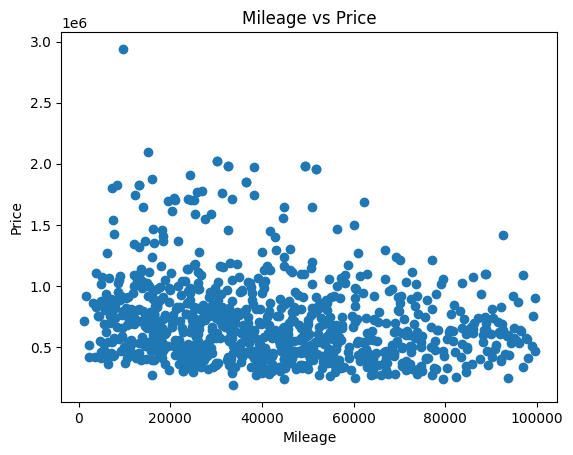

In [14]:
#Q1: clean data and EDA

#lowecase and underscores fixed
cars.columns = [col.strip().lower().replace(" ", "_") for col in cars.columns]

cars = cars.drop_duplicates()

print("Missing values:\n", cars.isnull().sum())
cars = cars.dropna()

print("\nData types:\n", cars.dtypes)


#EDA
print(cars.describe())

# Scatter plot: mileage vs price
plt.figure()
plt.scatter(cars['mileage_run'], cars['price'])
plt.title("Mileage vs Price")
plt.xlabel("Mileage")
plt.ylabel("Price")
plt.show()


In [23]:
#Q2
cat_cols = cars.select_dtypes(include=['object']).columns
print(cat_cols)

cars = pd.get_dummies(cars, columns=cat_cols, drop_first=True)


Index([], dtype='object')


In [30]:
#Q3
from sklearn.model_selection import train_test_split

#predicting price
y = cars['price']
X = cars.drop('price', axis=1)

X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2, random_state=42)

print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)

Training set size: (713, 45)
Test set size: (179, 45)


In [35]:
#Q4
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

#model 1 that includes all features
model1 = LinearRegression()
model1.fit(X_train, y_train)

y_train_pred1 = model1.predict(X_train)
y_test_pred1 = model1.predict(X_test)

rmse_train1 = np.sqrt(mean_squared_error(y_train, y_train_pred1))
rmse_test1 = np.sqrt(mean_squared_error(y_test, y_test_pred1))

r2_train1 = r2_score(y_train, y_train_pred1)
r2_test1 = r2_score(y_test, y_test_pred1)

#model 2 for year,
selected_features = ['make_year', 'mileage_run', 'seating_capacity']
selected_features = [col for col in selected_features if col in X_train.columns]

model2 = LinearRegression()
model2.fit(X_train[selected_features], y_train)

y_train_pred2 = model2.predict(X_train[selected_features])
y_test_pred2 = model2.predict(X_test[selected_features])

rmse_train2 = np.sqrt(mean_squared_error(y_train, y_train_pred2))
rmse_test2 = np.sqrt(mean_squared_error(y_test, y_test_pred2))

r2_train2 = r2_score(y_train, y_train_pred2)
r2_test2 = r2_score(y_test, y_test_pred2)

print("MODEL 1 (All Features)")
print("Train RMSE:", rmse_train1)
print("Test RMSE:", rmse_test1)
print("Train R2:", r2_train1)
print("Test R2:", r2_test1)

print("\nMODEL 2: make year, mileage, seating capacity")
print("Train RMSE:", rmse_train2)
print("Test RMSE:", rmse_test2)
print("Train R2:", r2_train2)
print("Test R2:", r2_test2)


MODEL 1 (All Features)
Train RMSE: 132423.5846232982
Test RMSE: 194746.37413447307
Train R2: 0.8473123399737563
Test R2: 0.7577387709686392

MODEL 2: make year, mileage, seating capacity
Train RMSE: 281396.1904572723
Test RMSE: 338991.3714283734
Train R2: 0.310539028102633
Test R2: 0.26595540874278867


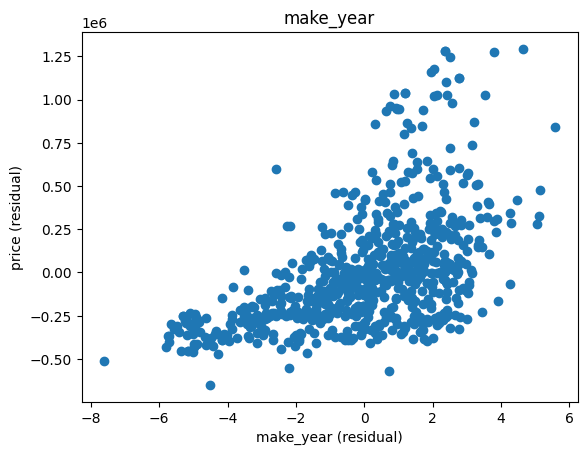

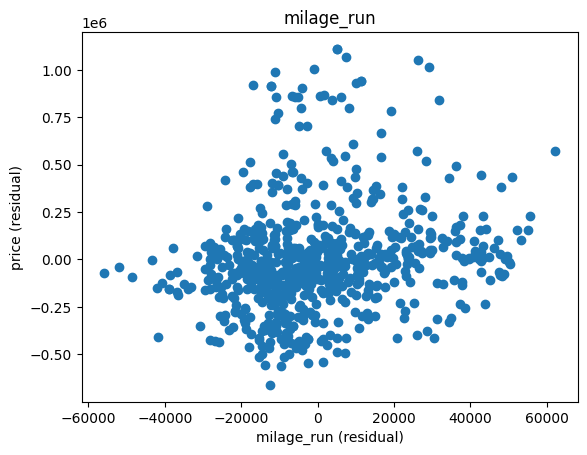

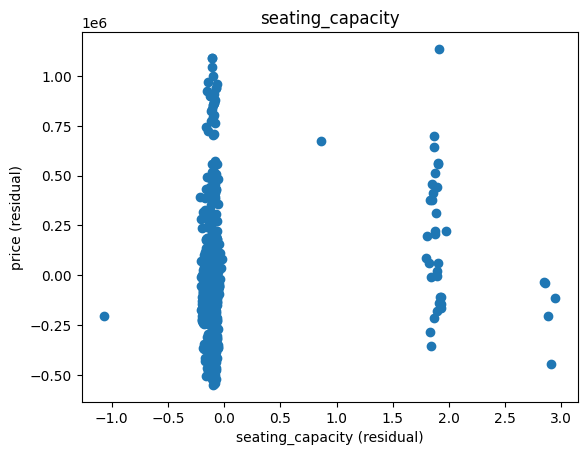

In [40]:
#Q5
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# make_year
other_vars = ['mileage_run', 'seating_capacity']

model_y = LinearRegression()
model_y.fit(X_train[other_vars], y_train)
y_resid = y_train - model_y.predict(X_train[other_vars])

model_x = LinearRegression()
model_x.fit(X_train[other_vars], X_train['make_year'])
x_resid = X_train['make_year'] - model_x.predict(X_train[other_vars])

plt.figure()
plt.scatter(x_resid, y_resid)
plt.title("make_year")
plt.xlabel("make_year (residual)")
plt.ylabel("price (residual)")
plt.show()

# milage_run
other_vars = ['make_year', 'seating_capacity']

model_y = LinearRegression()
model_y.fit(X_train[other_vars], y_train)
y_resid = y_train - model_y.predict(X_train[other_vars])

model_x = LinearRegression()
model_x.fit(X_train[other_vars], X_train['mileage_run'])
x_resid = X_train['mileage_run'] - model_x.predict(X_train[other_vars])

plt.figure()
plt.scatter(x_resid, y_resid)
plt.title("milage_run")
plt.xlabel("milage_run (residual)")
plt.ylabel("price (residual)")
plt.show()


# seating_capacity
other_vars = ['make_year', 'mileage_run']

model_y = LinearRegression()
model_y.fit(X_train[other_vars], y_train)
y_resid = y_train - model_y.predict(X_train[other_vars])

model_x = LinearRegression()
model_x.fit(X_train[other_vars], X_train['seating_capacity'])
x_resid = X_train['seating_capacity'] - model_x.predict(X_train[other_vars])

plt.figure()
plt.scatter(x_resid, y_resid)
plt.title("seating_capacity")
plt.xlabel("seating_capacity (residual)")
plt.ylabel("price (residual)")
plt.show()

In [41]:
#Q6
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Log transform mileage
X_train['log_mileage'] = np.log(X_train['mileage_run'] + 1)
X_test['log_mileage'] = np.log(X_test['mileage_run'] + 1)

#interaction term
X_train['year_mileage'] = X_train['make_year'] * X_train['mileage_run']
X_test['year_mileage'] = X_test['make_year'] * X_test['mileage_run']


features = ['make_year', 'seating_capacity', 'log_mileage', 'year_mileage']


#fit - new model 3
model3 = LinearRegression()
model3.fit(X_train[features], y_train)

y_train_pred3 = model3.predict(X_train[features])
y_test_pred3 = model3.predict(X_test[features])

rmse_train3 = np.sqrt(mean_squared_error(y_train, y_train_pred3))
rmse_test3 = np.sqrt(mean_squared_error(y_test, y_test_pred3))

r2_train3 = r2_score(y_train, y_train_pred3)
r2_test3 = r2_score(y_test, y_test_pred3)

print("MODEL 3 (Transformed + Interaction)")
print("Train RMSE:", rmse_train3)
print("Test RMSE:", rmse_test3)
print("Train R2:", r2_train3)
print("Test R2:", r2_test3)

MODEL 3 (Transformed + Interaction)
Train RMSE: 277982.31824504555
Test RMSE: 338192.1625661378
Train R2: 0.3271665028644737
Test R2: 0.2694125078947014
